In [1]:
# Load dataset
import pandas as pd

df = pd.read_csv("students.csv")

# Shows first 4 rows
print(df.head())

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [2]:
# See number of rows and columns
print("Shape:", df.shape)

# Check each column type
print("\nData types:")

Shape: (15, 9)

Data types:


In [3]:
# Basic statistics like mean, min , max
print(df.describe())

            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2.800000   1.000000  

In [4]:
# Count how many passed and failed
print(df['passed'].value_counts())

passed
1    9
0    6
Name: count, dtype: int64


In [5]:
# Subjects columns
subjects =['math', 'science', 'english', 'history', 'pe']

# Average for passed students
print("Passed avg:")
print(df[df['passed'] == 1] [subjects].mean())

# Average for failed students
print("\nFailed avg:")
print(df[df['passed'] == 0] [subjects].mean())

Passed avg:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Failed avg:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [7]:
# Create average column
df['avg_total'] = df[subjects].mean(axis=1)

# Find higest avg student
top_student = df.loc[df['avg_total'].idxmax()]

print("Top student:", top_student['name'])

Top student: Diana


In [8]:
# New column for plotting
df["avg_score"] = df[subjects].mean(axis=1)

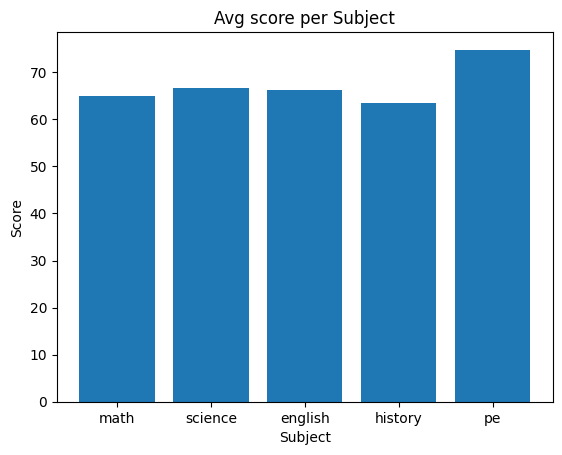

In [13]:
# BAR CHART

import matplotlib.pyplot as plt

# Average score per subject
avg = df[subjects].mean()

plt.bar(subjects, avg)
plt.title("Avg score per Subject")
plt.xlabel("Subject")
plt.ylabel("Score")

plt.savefig("plot1_bar.png")
plt.show()

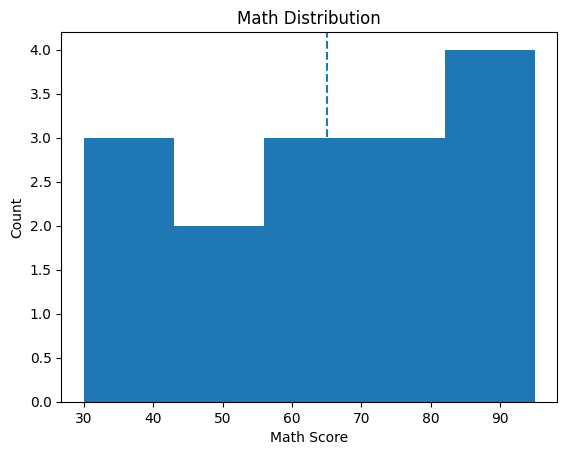

In [15]:
# HISTOGRAM

# Math score distribution
plt.hist(df['math'], bins=5)

# Mean line
plt.axvline(df['math'].mean(),linestyle='dashed')
plt.title("Math Distribution")
plt.xlabel("Math Score")
plt.ylabel("Count")

plt.savefig("plot2_hist.png")
plt.show()


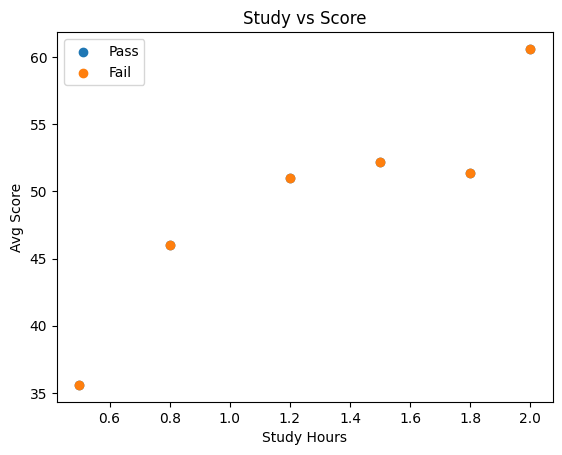

In [16]:
# SCATTER PLOT

# Split data
pass_df = df[df['passed']== 1]
pass_df = df[df['passed']== 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Fail')

plt.xlabel("Study Hours")
plt.ylabel("Avg Score")
plt.title("Study vs Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

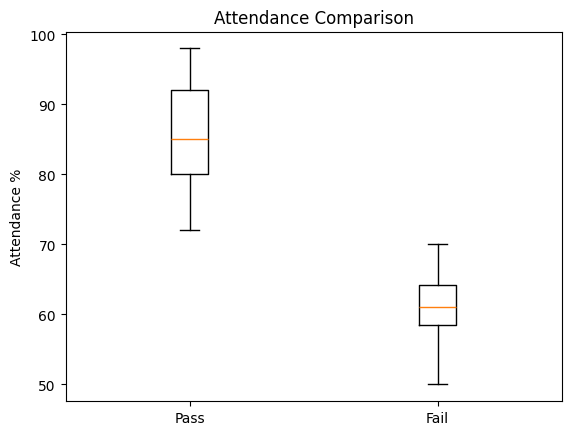

In [28]:
#BOX PLOT

# Attendance data
pass_att = df[df['passed']==1]['attendance_pct']
fail_att = df[df['passed']==0]['attendance_pct']

plt.boxplot([pass_att, fail_att])
plt.xticks([1, 2], ['Pass', 'Fail'])

plt.title("Attendance Comparison")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()

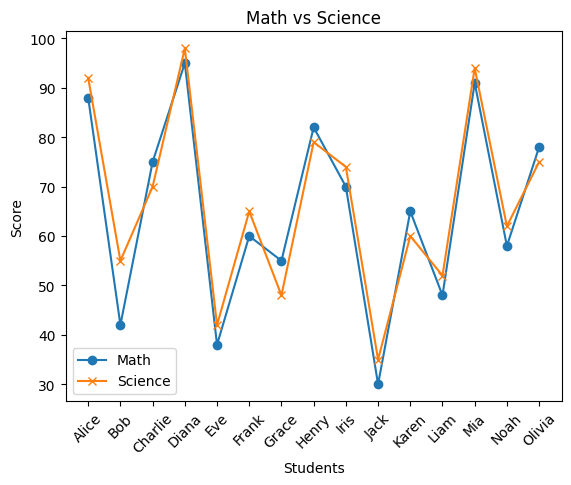

In [30]:
# LINE PLOT

plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')

plt.xticks(rotation=45)
plt.title("Math vs Science")
plt.xlabel("Students")
plt.ylabel("Score")
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

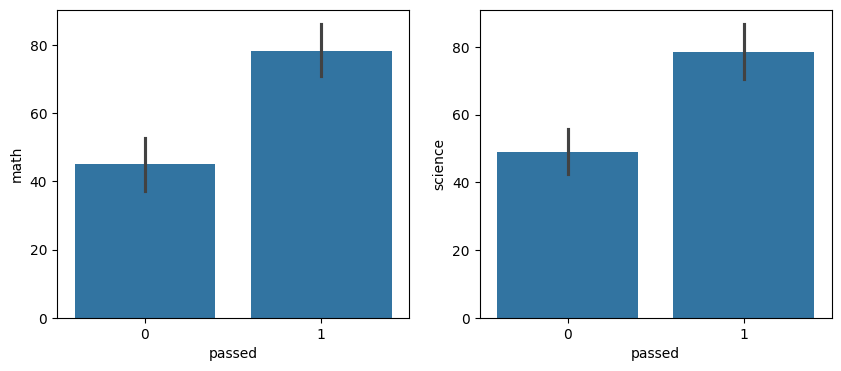

In [31]:
# SEABORN CHART

import seaborn as sns

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math')

plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science')

plt.savefig("plot6_seaborn_bar.png")
plt.show()

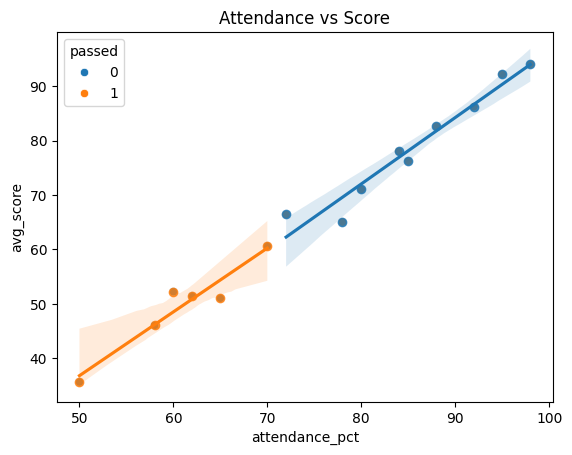

In [33]:
# SEABORN SCATTER
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue= 'passed')

sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score')

plt.title("Attendance vs Score")

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

#While working on this task, i found Seaborn easier because it creates better looking graps with fewer lines of code.
#It automatically handles styling and grouping, especially for regression plots.
#On other hand, Matplotlib required more manual work for formatting and customization.

In [34]:
# ML Setup

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [36]:
# Features and Target

X = df[['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']]
y = df['passed']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaler data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
# Train model

model = LogisticRegression ()

model.fit(X_train, y_train)

print("Train accuracy:", model.score(X_train, y_train))

Train accuracy: 1.0


In [41]:
# Test model

y_pred = model.predict(X_test)

print("Test accuracy:", model.score(X_test, y_test))

# Show results
for i in range(len(y_test)):
  print("Actual:", y_test.iloc[i], "Predict:", y_pred[i])

Test accuracy: 1.0
Actual: 0 Predict: 0
Actual: 0 Predict: 0
Actual: 1 Predict: 1


In [43]:
# Feature Importance

coef = model.coef_[0]
features = X.columns

for f, c in zip(features, coef):
  print(f, ":", c)

math : 0.43794393086873595
science : 0.3230097624690249
english : 0.8125127982724648
history : 0.26292892629062437
pe : 0.47497406284967797
attendance_pct : 0.521876340433209
study_hours_per_day : 0.4844326627100155


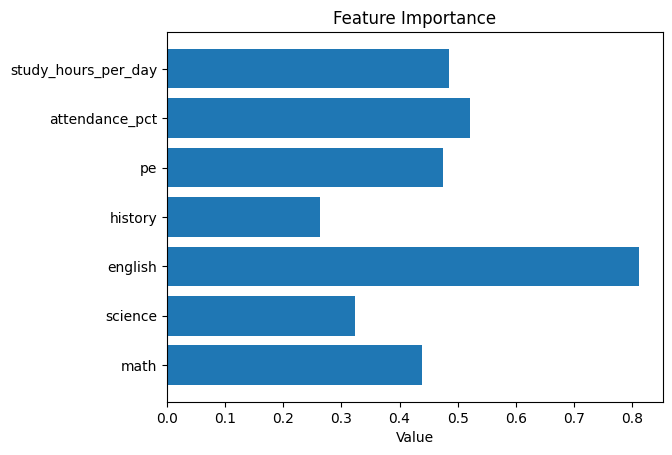

In [44]:
# Feature plot

plt.barh(features, coef)

plt.title("Feature Importance")
plt.xlabel("Value")

plt.show()

In [46]:
# New student

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]  # order must match feature columns

new_scaled = scaler.transform(new_student)

pred = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

print("Prediction:", "Pass" if pred[0]==1
else "Fail")
print("Probability:",prob)

Prediction: Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
